In [1]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Bayes
import pymc as pm
import pytensor
import pytensor.tensor as pt
rng = np.random.default_rng(42)

In [2]:
# Function to read the mapping from Excel
def read_mapping_from_excel(file_path):
    # Read the Excel file, assuming the mapping is in the first sheet
    mapping_df = pd.read_excel(file_path, sheet_name=0)
    
    # Create a dictionary mapping MagSusRecord to Trench
    record_to_trench_map = dict(zip(mapping_df['magsus_rec_id'], mapping_df['trench']))
    
    return record_to_trench_map

# Function to process a single CSV file
def process_csv(file_path, record_id, record_to_trench_map):
    # Read the CSV file, skipping first two and last three lines
    data = pd.read_csv(file_path, skiprows=3, skipfooter=3, engine='python')
    
    # Extract relevant columns
    data = data.iloc[:, [0, 1]]  # Columns: scan_idx and susceptibility
    data.columns = ['scan_idx', 'susceptibility']
    
    # Add Record_ID and Trench_ID
    data['record_id'] = record_id
    data['trench_id'] = record_to_trench_map.get(record_id, 'Unknown')
    
    return data[['record_id', 'trench_id', 'scan_idx', 'susceptibility']]

# Read the mapping from the Excel file
excel_path = '../Data/MagSusMap.xlsx'
record_to_trench_map = read_mapping_from_excel(excel_path)

# List of files and corresponding record IDs
files = []

# Base path for the data folder
base_path = '../Data/kt20_0467/'

# Loop over each row in the mapping DataFrame
for record_number in record_to_trench_map.keys():
    folder_name = f"{record_number}"     # Create the folder name from the record number
    file_name = f"record_scanner_10khz_{record_number}.csv"  # Create the CSV file name
    file_path = f"{base_path}{folder_name}/{file_name}"  # Construct the full file path
    
    # Append the file path and record number as a tuple to the list
    files.append((file_path, record_number))

# Process all files and concatenate the results
magsus = pd.concat([process_csv(file, record_id, record_to_trench_map) for file, record_id in files])

# Display the combined DataFrame
print(magsus)


    record_id  trench_id  scan_idx  susceptibility
0           8          1         1          0.0000
1           8          1         2          0.0055
2           8          1         3          0.0180
3           8          1         4          0.0413
4           8          1         5          0.0415
..        ...        ...       ...             ...
43         64          8        44          0.0174
44         64          8        45          0.0091
45         64          8        46          0.0442
46         64          8        47          0.0391
47         64          8        48          0.0252

[1737 rows x 4 columns]


In [3]:
# depth data

trench_map_depth = pd.read_excel(excel_path)

# Create a dictionary with keys as (trench_id, record_id) and values as MaxDepth_cm
trench_depths = trench_map_depth.set_index(['trench', 'magsus_rec_id'])['max_dbs_cm'].to_dict()

# this function produces depth sequences assuming a linear relationship between 
# scan index (essentially time-series index) and physical depth along the 
# profile wall

def add_depth_column(df, trench_depths):
    """
    Adds a depth column to the DataFrame based on the scan index and the given top/bottom depths for each trench.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing magnetic susceptibility scan data.
    trench_depths (dict): Dictionary with (trench_id, record_id) as keys and MaxDepth_cm as values.
    
    Returns:
    pd.DataFrame: DataFrame with an additional column 'depth' representing the calculated depth for each scan.
    """
    def calculate_depth(row):
        # Get the bottom depth for the current trench and record
        max_depth = trench_depths[(row['trench_id'], row['record_id'])]
        
        # Assuming top_depth is 0 for all trenches
        top_depth = 0.0
        
        # Calculate the total number of scans in this trench's record
        max_scan_idx = df[(df['trench_id'] == row['trench_id']) & 
                          (df['record_id'] == row['record_id'])]['scan_idx'].max()
        
        # Calculate depth increment per scan index
        depth_increment = (max_depth - top_depth) / (max_scan_idx - 1)
        
        # Calculate the depth for the current scan index
        depth = top_depth + (row['scan_idx'] - 1) * depth_increment
        
        return depth

    # Apply the calculate_depth function to each row and add the resulting column to the dataframe
    df['depth'] = df.apply(calculate_depth, axis=1)
    
    return df

magsus = add_depth_column(magsus, trench_depths)
magsus.to_csv('../Output/magsus_scans.csv', index=False)
magsus

,record_id,trench_id,scan_idx,susceptibility,depth
0,8,1,1,0.0000,0.000000
1,8,1,2,0.0055,1.774194
2,8,1,3,0.0180,3.548387
3,8,1,4,0.0413,5.322581
4,8,1,5,0.0415,7.096774
...,...,...,...,...,...
43,64,8,44,0.0174,94.234043
44,64,8,45,0.0091,96.425532
45,64,8,46,0.0442,98.617021
46,64,8,47,0.0391,100.808511


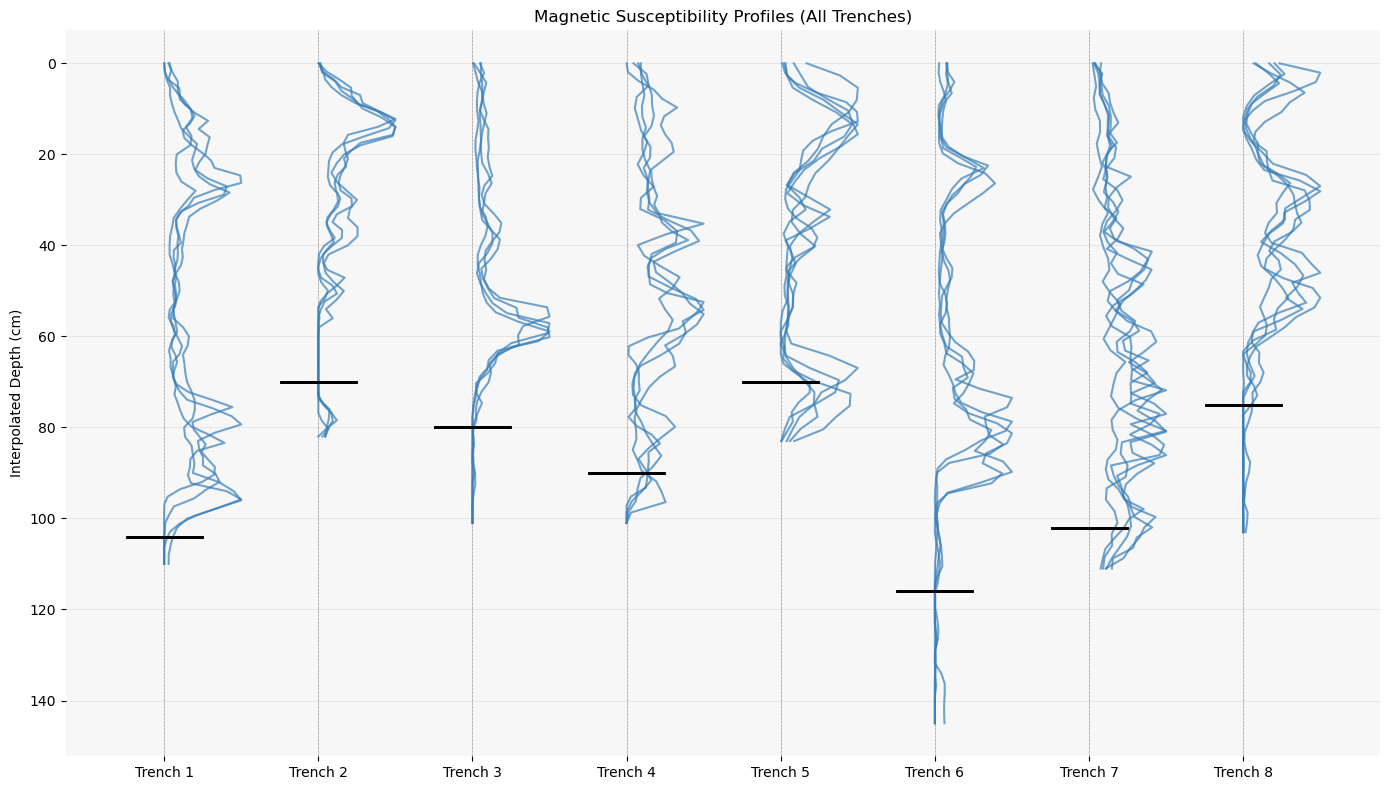

In [4]:
# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Sort the magsus DataFrame by trench_id and record_id
magsus = magsus.sort_values(by=['trench_id', 'record_id', 'scan_idx'])

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define a single color for all plots
uniform_color = '#377eb8'

# Plot each trench
offsets = []  # To store offsets for x-ticks
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    offsets.append(offset)
    
    # Add vertical zero line for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=offset - 0.5, xmax=offset + 0.5, color='black', linewidth=2)

# Set the x-ticks to the trench offsets and label them with the trench numbers
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {trench}' for trench in magsus['trench_id'].unique()])

# Invert y-axis to have depth increase downward
ax.invert_yaxis()

# Set labels and title
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches)')

# Apply minimal theme styling (like ggplot2's theme_minimal)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')  # Light grey background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the layout and show the plot
plt.tight_layout()

# Save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles.png', dpi=300, bbox_inches='tight', format='png')
plt.savefig('../Output/magnetic_susceptibility_profiles.pdf', dpi=300, bbox_inches='tight', format='pdf')


# Display it
plt.show()


In [5]:
# Normalize susceptibility values for each record
def normalize_susceptibility(data):
    data['susceptibility'] = data.groupby('record_id')['susceptibility'].transform(lambda x: x / x.max())
    return data

# Normalize the magsus DataFrame
magsus = normalize_susceptibility(magsus)

# Sort the magsus DataFrame by trench_id and record_id
magsus = magsus.sort_values(by=['trench_id', 'record_id', 'scan_idx'])

# Define a single color for all plots
uniform_color = '#377eb8'

# Iterate over each trench and plot separately
for trench in magsus['trench_id'].unique():
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Create a figure for each trench
    fig, ax = plt.subplots(figsize=(6, 8))  # Adjust the size if needed
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile without an offset and with transparency
        ax.plot(record_data['susceptibility'],
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=-0.5, xmax=0.5, color='black', linewidth=2)
    
    # Invert y-axis to have depth increase downward
    ax.invert_yaxis()

    # Set labels and title
    ax.set_ylabel('Interpolated Depth (cm)')
    ax.set_xlabel('Normalized Magnetic Susceptibility')
    ax.set_title(f'Magnetic Susceptibility Profile - Trench {trench}')

    # Apply minimal theme styling (like ggplot2's theme_minimal)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Save the plot as a PDF and SVG with a transparent background
    plt.savefig(f'../Output/Trench_{trench}_MagSus_Profile.pdf', dpi=300, bbox_inches='tight', format='pdf', transparent=True)
    plt.savefig(f'../Output/Trench_{trench}_MagSus_Profile.svg', dpi=300, bbox_inches='tight', format='svg', transparent=True)

    # Close the figure to avoid display
    plt.close(fig)


In [6]:
# Load the CSV file into a Pandas DataFrame
file_path = '../Data/kkpp24_c14.csv'
c14_data = pd.read_csv(file_path)

# Extract 'trench' and 'depth' from 'sample_id' and convert them to integers
import re

c14_data['trench'] = c14_data['sample_id'].apply(lambda x: int(x.split('_')[1]))  # Extract trench as an integer
c14_data['depth'] = c14_data['sample_id'].apply(lambda x: int(re.sub(r'\D', '', x.split('_')[2])))  # Remove non-numeric characters from depth


# Step 3: Display the updated DataFrame
print(c14_data.head())


   ugams     sample_id  material  d13C_ppm  ybp_14C  error_14C    pMC  \
0  73631   KKPP24_1_10  sediment    -24.83     1120       20.0  86.95   
1  73632   KKPP24_1_50  sediment    -26.35     4340       25.0  58.27   
2  73633  KKPP24_1_100  sediment    -26.63     3090       20.0  68.10   
3  73634   KKPP24_2_10  sediment    -23.75     1530       20.0  82.67   
4  73635   KKPP24_2_40  sediment    -27.13     4130       20.0  59.78   

   error_pmc  trench  depth  
0       0.21       1     10  
1       0.17       1     50  
2       0.18       1    100  
3       0.21       2     10  
4       0.17       2     40  


In [7]:
# Import the full module to ensure initialization code (e.g., intcal20) runs
import chronocluster.distributions

# Import the specific calibration class
from chronocluster.distributions import calrcarbon

# access calrcarbon without referring to the full namespace
intcal20 = chronocluster.distributions.intcal20  # Access the preloaded calibration curve

# Use calrcarbon directly
cal = calrcarbon(intcal20, c14_mean=1120, c14_err=20)

# Create a list of calrcarbon objects using the loaded IntCal20 calibration curve
calibrations = [calrcarbon(intcal20, c14_mean=-row['ybp_14C'], c14_err=row['error_14C']) for _, row in c14_data.iterrows()]

# get calibrated means and add them to the c14_data df
c14_data['ybp_cal']  = [round(cal.mean()) for cal in calibrations]

c14_data.to_csv('../Output/c14_data.csv', index=False)

c14_data


,ugams,sample_id,material,d13C_ppm,ybp_14C,error_14C,pMC,error_pmc,trench,depth,ybp_cal
0,73631,KKPP24_1_10,sediment,-24.83,1120,20.00,86.95,0.21,1,10,-1013
1,73632,KKPP24_1_50,sediment,-26.35,4340,25.00,58.27,0.17,1,50,-4906
2,73633,KKPP24_1_100,sediment,-26.63,3090,20.00,68.10,0.18,1,100,-3302
3,73634,KKPP24_2_10,sediment,-23.75,1530,20.00,82.67,0.21,2,10,-1400
4,73635,KKPP24_2_40,sediment,-27.13,4130,20.00,59.78,0.17,2,40,-4681
5,73636,KKPP24_2_80,sediment,-28.43,7880,30.00,37.50,0.13,2,80,-8687
6,73637,KKPP24_3_10,sediment,-19.71,950,20.00,88.87,0.21,3,10,-850
7,73638,KKPP24_3_50,sediment,-23.85,2000,20.00,77.92,0.19,3,50,-1938
8,73639,KKPP24_3_90,sediment,-25.43,3850,20.00,61.90,0.17,3,90,-4266
9,73640,KKPP24_4_10,sediment,-22.02,490,20.00,94.13,0.23,4,10,-521


In [8]:
c14_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ugams      38 non-null     int64  
 1   sample_id  38 non-null     object 
 2   material   38 non-null     object 
 3   d13C_ppm   38 non-null     float64
 4   ybp_14C    38 non-null     int64  
 5   error_14C  38 non-null     float64
 6   pMC        38 non-null     float64
 7   error_pmc  37 non-null     float64
 8   trench     38 non-null     int64  
 9   depth      38 non-null     int64  
 10  ybp_cal    38 non-null     int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 3.4+ KB


/tmp/ipykernel_10849/1819911660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=12)
/tmp/ipykernel_10849/1819911660.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12)
/tmp/ipykernel_10849/1819911660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=12)
/tmp/ipykernel_10849/1819911660.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12)
/tmp/ipykernel_10849/1819911660.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

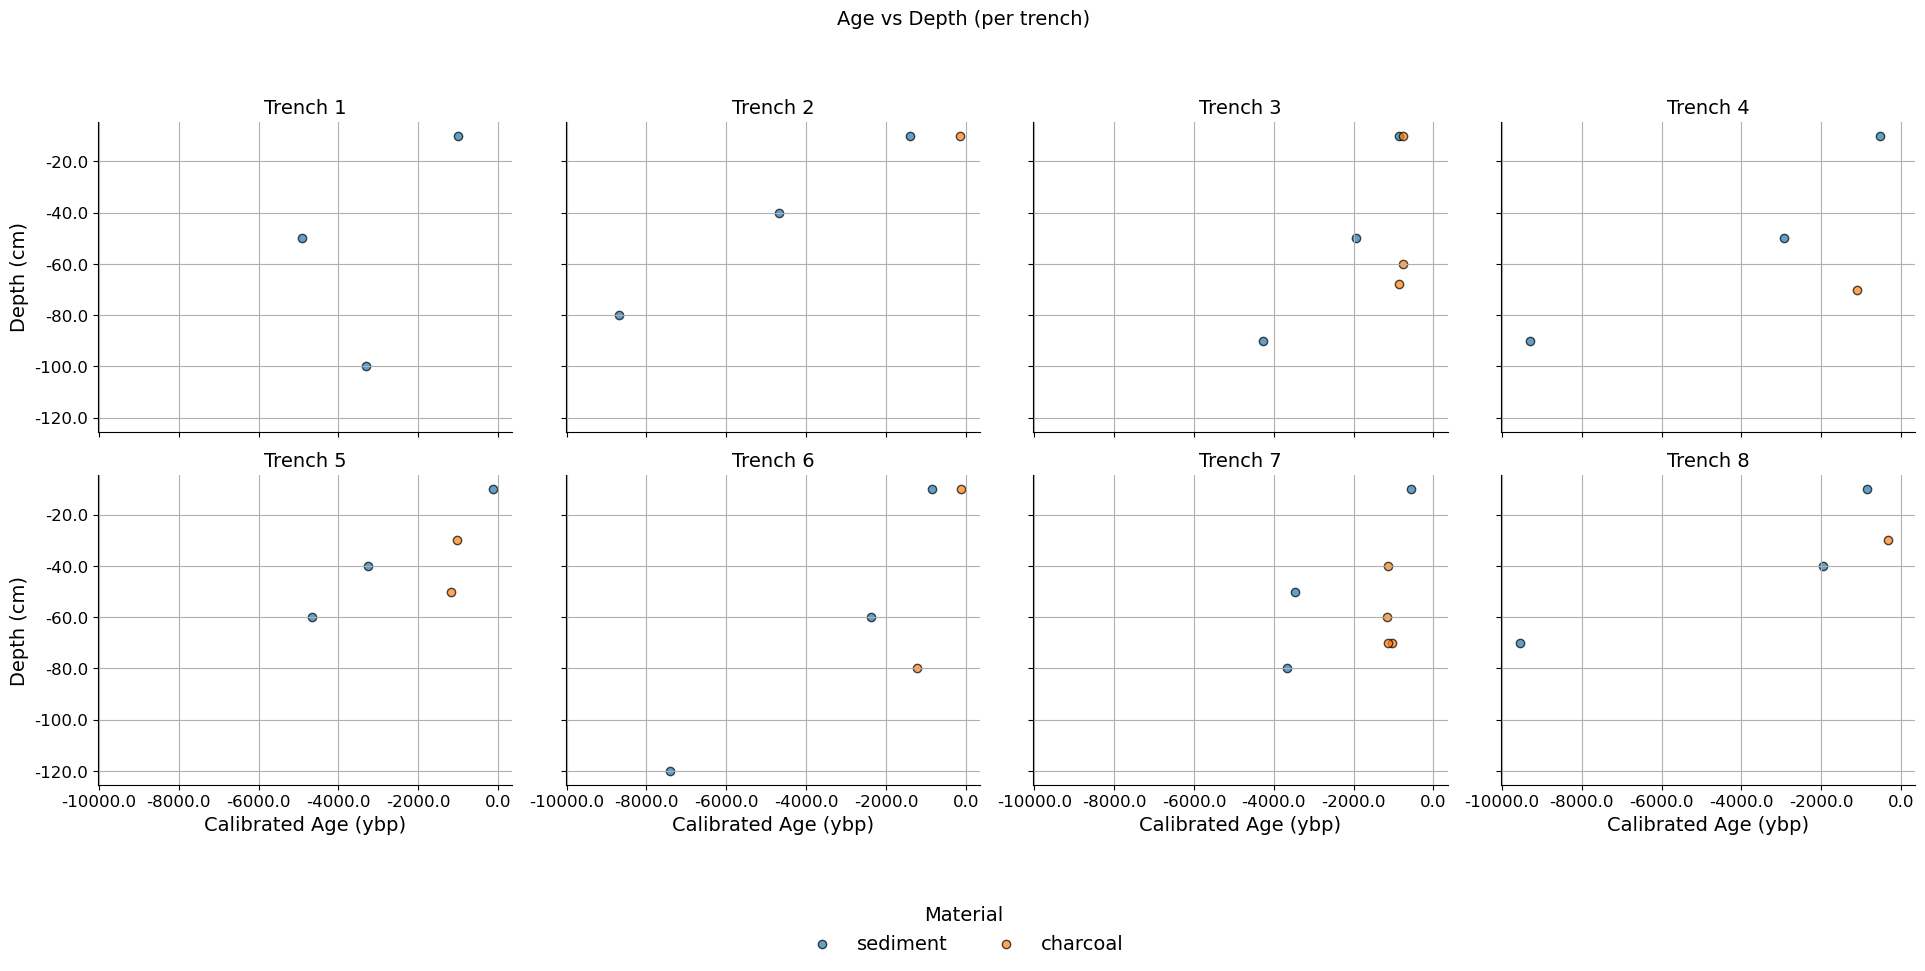

In [9]:
# make DBS negative for plotting
c14_data["depth_neg"] = -c14_data["depth"]

# Create the FacetGrid
g = sns.FacetGrid(c14_data, col="trench", hue="material", col_wrap=4, height=4, sharex=True, sharey=True)

# Plot scatter in each facet
g.map(plt.scatter, "ybp_cal", "depth_neg", edgecolor="black", alpha=0.7)

# Set axis labels and facet titles
g.set_axis_labels("Calibrated Age (ybp)", "Depth (cm)", fontsize=14)
g.set_titles("Trench {col_name}", size=14)

# Add a global title
plt.suptitle("Age vs Depth (per trench)", fontsize=14, y=1.05)

# Move the legend **outside the grid**.
g.add_legend(title="Material", loc='center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)

g.legend.get_title().set_fontsize(14)

# Adjust each axis and add grid
for ax in g.axes.flat:
    ax.grid(True)
    ax.set_xticklabels(ax.get_xticks(), fontsize=12)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 1])

# Show plot
plt.show()


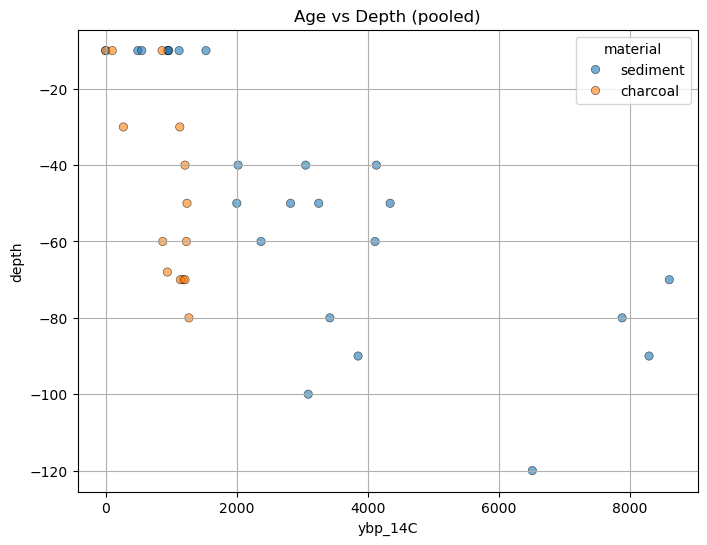

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data,
    x='ybp_14C',
    y='depth_neg',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('ybp_14C')
ax.set_ylabel('depth')
ax.set_title('Age vs Depth (pooled)')

plt.grid(True)
plt.show()

/tmp/ipykernel_10849/3691520264.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=12)
/tmp/ipykernel_10849/3691520264.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12)
/tmp/ipykernel_10849/3691520264.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=12)
/tmp/ipykernel_10849/3691520264.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12)
/tmp/ipykernel_10849/3691520264.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

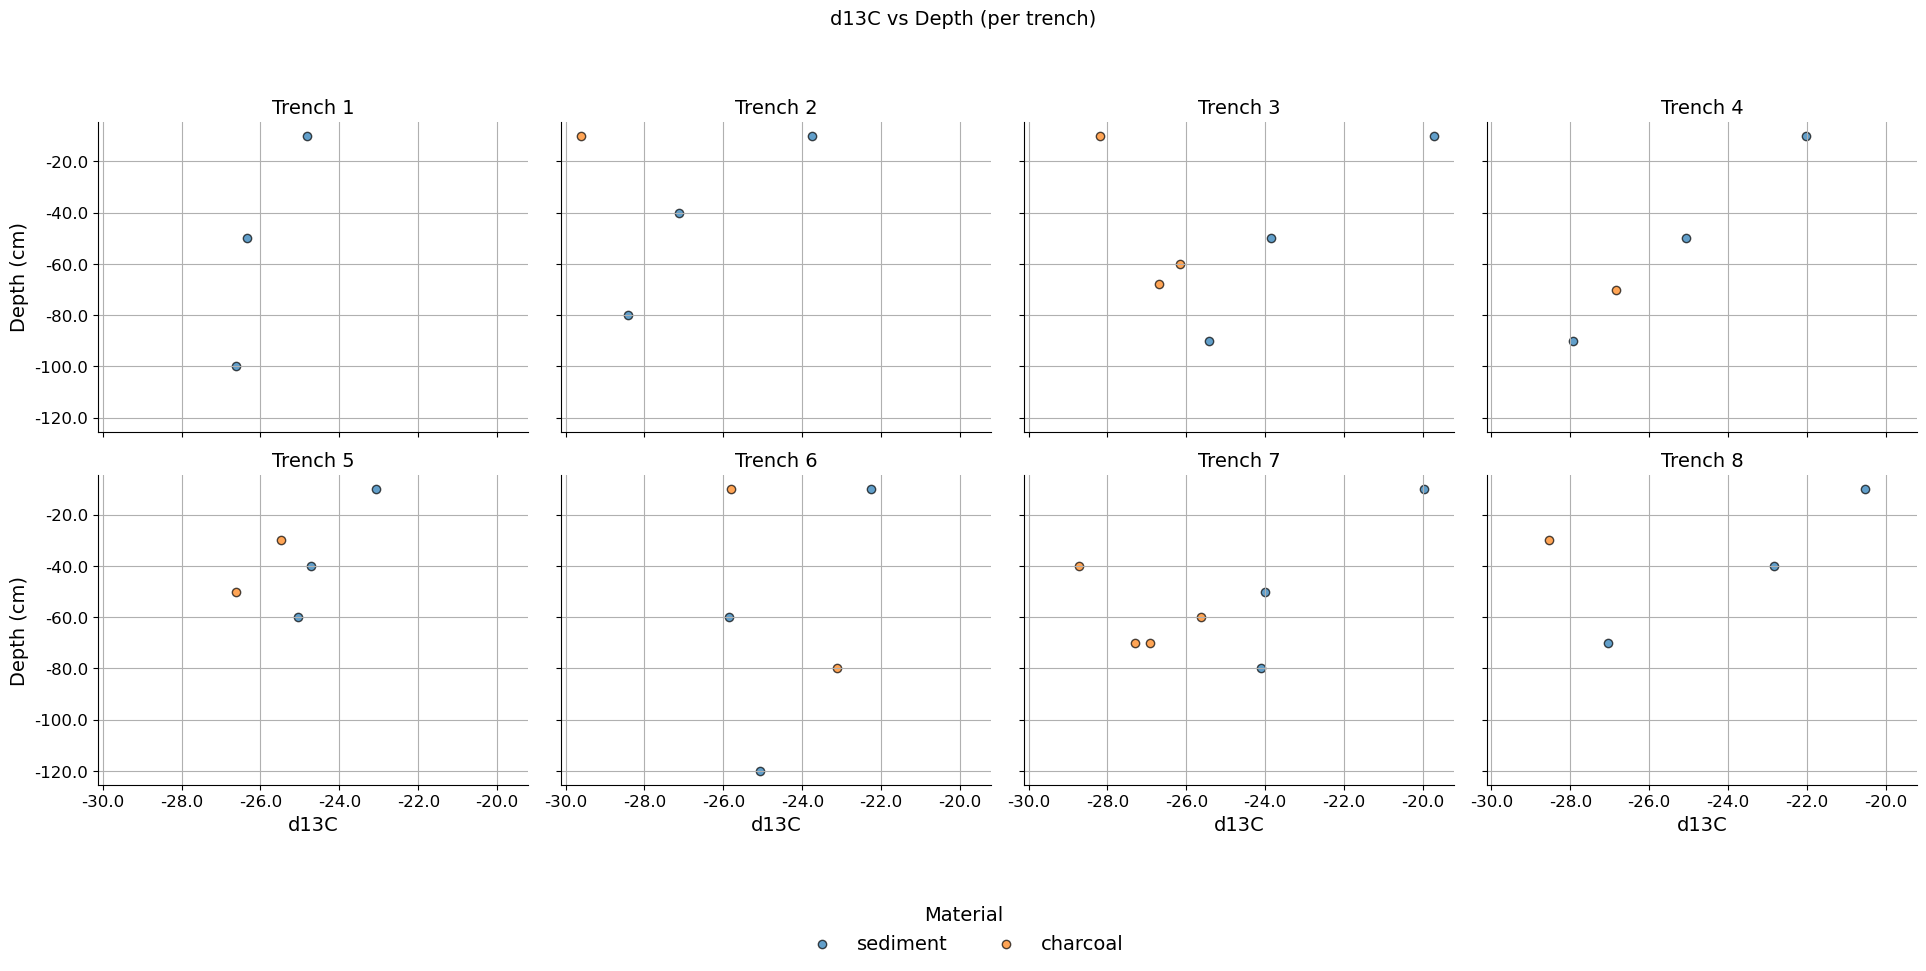

In [14]:
# make DBS negative for plotting
c14_data["depth_neg"] = -c14_data["depth"]

# Create the FacetGrid
g = sns.FacetGrid(c14_data, col="trench", hue="material", col_wrap=4, height=4, sharex=True, sharey=True)

# Plot scatter in each facet
g.map(plt.scatter, "d13C_ppm", "depth_neg", edgecolor="black", alpha=0.7)

# Set axis labels and facet titles
g.set_axis_labels("d13C", "Depth (cm)", fontsize=14)
g.set_titles("Trench {col_name}", size=14)

# Add a global title
plt.suptitle("d13C vs Depth (per trench)", fontsize=14, y=1.05)

# Move the legend **outside the grid**.
g.add_legend(title="Material", loc='center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=14)

g.legend.get_title().set_fontsize(14)

# Adjust each axis and add grid
for ax in g.axes.flat:
    ax.grid(True)
    ax.set_xticklabels(ax.get_xticks(), fontsize=12)
    ax.set_yticklabels(ax.get_yticks(), fontsize=12)

# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0, 1, 1])

# Show plot
plt.show()


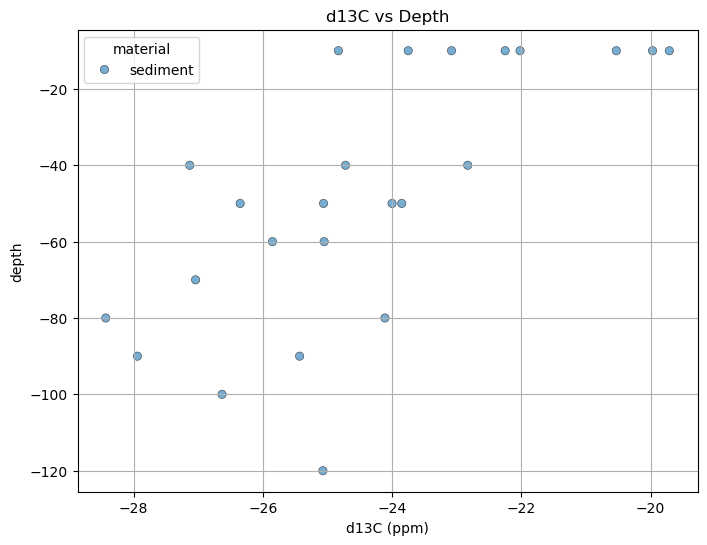

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=c14_data[c14_data['material'] == 'sediment'],
    x='d13C_ppm',
    y='depth_neg',
    hue='material',
    palette='tab10',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

ax.set_xlabel('d13C (ppm)')
ax.set_ylabel('depth')
ax.set_title('d13C vs Depth')

plt.grid(True)
plt.show()

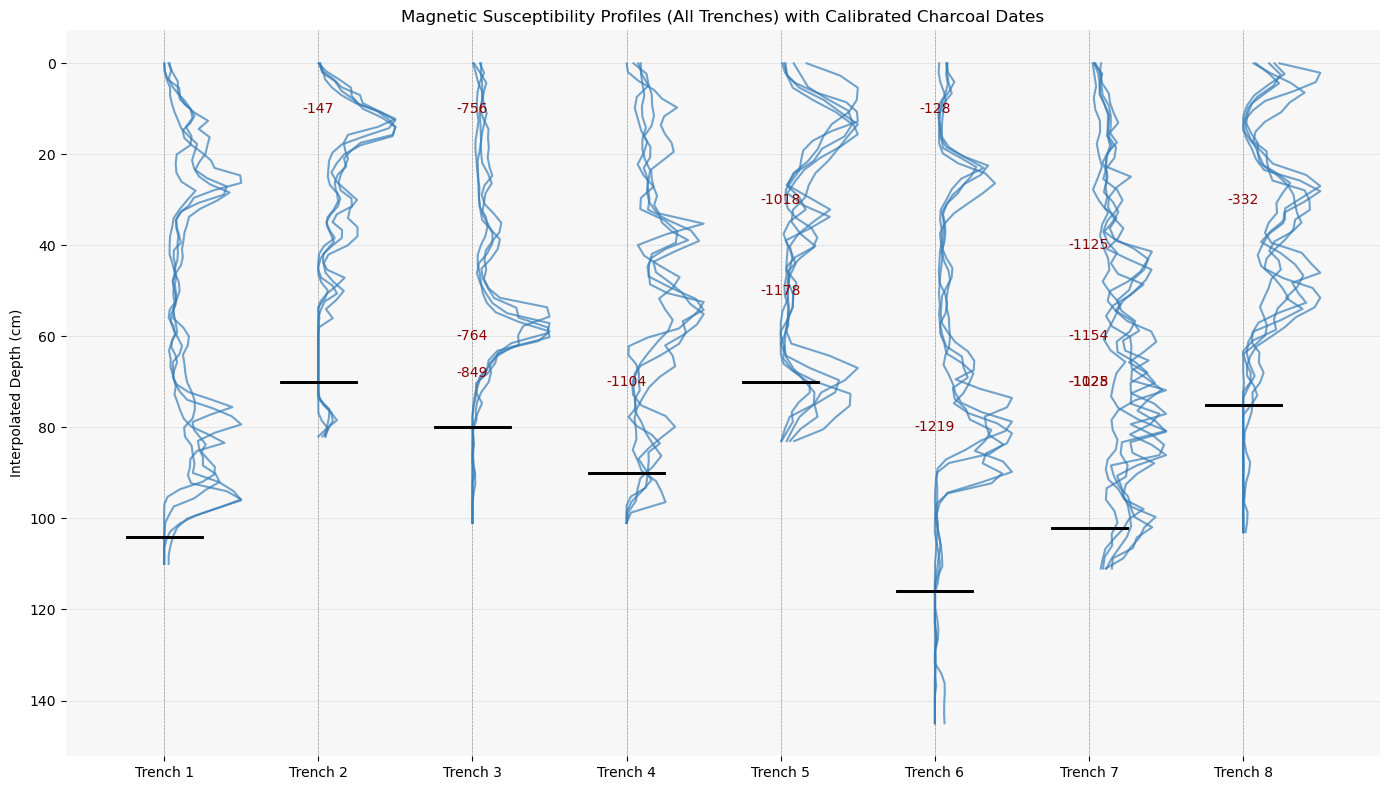

In [12]:
# Filter c14_data for charcoal dates
charcoal_data = c14_data[c14_data['material'] == 'charcoal']

# Create a figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define a single color for all plots
uniform_color = '#377eb8'

# Plot each trench
offsets = []  # To store offsets for x-ticks
for i, trench in enumerate(magsus['trench_id'].unique()):
    trench_data = magsus[magsus['trench_id'] == trench]
    
    # Get unique record IDs for this trench
    record_ids = trench_data['record_id'].unique()
    
    # Horizontal offset for separating trenches
    offset = i * 2  # Adjust spacing as needed
    offsets.append(offset)
    
    # Add vertical zero line for this trench
    ax.axvline(x=offset, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
    
    for record_id in record_ids:
        record_data = trench_data[trench_data['record_id'] == record_id]
        
        # Plot each profile with an offset and transparency
        ax.plot(record_data['susceptibility'] + offset,
                record_data['depth'],
                color=uniform_color,
                alpha=0.7)  # Transparency
        
        # Get the sterile depth for this trench and record_id
        sterile_depth = trench_map_depth[(trench_map_depth['trench'] == trench) & 
                                         (trench_map_depth['magsus_rec_id'] == record_id)]['sterile_dbs_cm'].values
        
        # If sterile depth exists, plot a short horizontal line at that depth
        if len(sterile_depth) > 0:
            ax.hlines(y=sterile_depth, xmin=offset - 0.5, xmax=offset + 0.5, color='black', linewidth=2)

    # Add calibrated radiocarbon dates for charcoal material
    trench_charcoal_data = charcoal_data[charcoal_data['trench'] == trench]
    for _, row in trench_charcoal_data.iterrows():
        ax.text(x=offset, y=row['depth'], s=f"{int(row['ybp_cal'])}", 
                color='darkred', fontsize=10, ha='center', va='center')

# Set the x-ticks to the trench offsets and label them with the trench numbers
ax.set_xticks(offsets)
ax.set_xticklabels([f'Trench {trench}' for trench in magsus['trench_id'].unique()])

# Invert y-axis to have depth increase downward
ax.invert_yaxis()

# Set labels and title
ax.set_ylabel('Interpolated Depth (cm)')
ax.set_xlabel('')
ax.set_title('Magnetic Susceptibility Profiles (All Trenches) with Calibrated Charcoal Dates')

# Apply minimal theme styling (like ggplot2's theme_minimal)
ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.7, alpha=0.5)
ax.set_facecolor('#f7f7f7')  # Light grey background
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Adjust the layout and show the plot
plt.tight_layout()

# Save the plot
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.png', dpi=300, bbox_inches='tight', format='png')
plt.savefig('../Output/magnetic_susceptibility_profiles_with_charcoal_dates.pdf', dpi=300, bbox_inches='tight', format='pdf')

# Display it
plt.show()


## Modelling the Process

In [3]:
# Study design
T = 8      # trenches
D = 50     # depth bins per trench
R = 4      # magsus scans per depth

coords = {
    "trench": np.arange(T),
    "depth": np.arange(D),
    "scan": np.arange(R),
    "depth_minus1": np.arange(D - 1),
}

# Convenience indexers
trench_ix = np.arange(T)
depth_ix = np.arange(D)


In [4]:

# Repro-friendly small helper
def logistic(a):
    return 1 / (1 + np.exp(-a))

In [5]:
# Simulate from the *true* generative model (for testing)
# True hyperparameters (tweak to taste)
mu_I_true = 0.0
tau_I_true = 0.5

sigma_I_t_true = rng.uniform(0.05, 0.25, size=T)  # trench-specific RW1 volatility

alpha_y_true = 0.0
beta_y_true = 1.0
sigma_alpha_y_true = 0.4
sigma_beta_y_true = 0.3

alpha_z_true = -1.0   # baseline logit for presence
sigma_alpha_z_true = 0.6
beta_z_true = 0.9     # presence sensitivity to I

alpha_x_true = 0.0    # baseline log-mean for counts (given presence)
sigma_alpha_x_true = 0.5
beta_x_true = 0.5     # abundance sensitivity to I
phi_true = 6.0        # NB dispersion (larger → closer to Poisson)

sigma_y_true = 0.15   # magsus channel noise
sigma_scan_true = 0.05  # per-scan noise

# Trench-level effects
alpha_y_t_true = rng.normal(alpha_y_true, sigma_alpha_y_true, size=T)
beta_y_t_true  = rng.normal(beta_y_true,  sigma_beta_y_true,  size=T)
alpha_z_t_true = rng.normal(alpha_z_true, sigma_alpha_z_true, size=T)
alpha_x_t_true = rng.normal(alpha_x_true, sigma_alpha_x_true, size=T)

# Latent I (RW1 per trench)
I_true = np.zeros((D, T))
I_true[0, :] = rng.normal(mu_I_true, tau_I_true, size=T)
for t in trench_ix:
    eps = rng.normal(0.0, sigma_I_t_true[t], size=D-1)
    I_true[1:, t] = I_true[0, t] + np.cumsum(eps)

# Magnetic susceptibility (y) and 4 repeated scans
y_mean_true = alpha_y_t_true[np.newaxis, :] + beta_y_t_true[np.newaxis, :] * I_true
y_true = rng.normal(y_mean_true, sigma_y_true)                # latent magsus channel
y_obs = rng.normal(y_true[..., np.newaxis], sigma_scan_true)  # shape (D, T, R)

# Artifact presence (z)
p_true = logistic(alpha_z_t_true[np.newaxis, :] + beta_z_true * I_true)
z_true = rng.binomial(1, p_true)

# Artifact abundance (x) | presence (NB)
# NB(mean=mu, var=mu + mu^2/phi) → Poisson(Gamma) mixture draw:
mu_true = np.exp(alpha_x_t_true[np.newaxis, :] + beta_x_true * I_true)
x_true = np.zeros_like(z_true, dtype=int)

# Draw counts only where present
present_mask = z_true == 1
r = phi_true
# Poisson-Gamma mixture: Gamma(shape=r, scale=mu/r) then Poisson
mu_pres = mu_true[present_mask]
gamma_draw = rng.gamma(shape=r, scale=mu_pres / r)
x_true[present_mask] = rng.poisson(gamma_draw)


In [6]:
# PyMC model with RW1 and trench pooling
with pm.Model(coords=coords) as model:
    # --- Priors: trench-level pooling for magsus channel
    alpha_y = pm.Normal("alpha_y", 0.0, 1.0)
    beta_y  = pm.Normal("beta_y",  0.0, 1.0)
    sigma_alpha_y = pm.HalfNormal("sigma_alpha_y", 0.5)
    sigma_beta_y  = pm.HalfNormal("sigma_beta_y",  0.5)

    alpha_y_t = pm.Normal("alpha_y_t", alpha_y, sigma_alpha_y, dims="trench")
    beta_y_t  = pm.Normal("beta_y_t",  beta_y,  sigma_beta_y,  dims="trench")

    # Artifact presence trench intercepts + global slope
    alpha_z    = pm.Normal("alpha_z", 0.0, 1.5)
    sigma_alpha_z = pm.HalfNormal("sigma_alpha_z", 0.7)
    alpha_z_t  = pm.Normal("alpha_z_t", alpha_z, sigma_alpha_z, dims="trench")
    beta_z     = pm.Normal("beta_z", 0.0, 1.5)

    # Artifact abundance trench intercepts + global slope
    alpha_x    = pm.Normal("alpha_x", 0.0, 1.0)
    sigma_alpha_x = pm.HalfNormal("sigma_alpha_x", 0.7)
    alpha_x_t  = pm.Normal("alpha_x_t", alpha_x, sigma_alpha_x, dims="trench")
    beta_x     = pm.Normal("beta_x", 0.0, 1.5)

    # Noise/dispersion
    sigma_y   = pm.HalfNormal("sigma_y", 0.5)
    sigma_scan = pm.HalfNormal("sigma_scan", 0.2)
    phi       = pm.HalfNormal("phi", 5.0)  # NB dispersion (>0)

    # Latent I RW1(σ_I_t) per trench
    mu_I  = pm.Normal("mu_I", 0.0, 1.0)
    tau_I = pm.HalfNormal("tau_I", 1.0)
    sigma_I_t = pm.HalfNormal("sigma_I_t", 0.5, dims="trench")

    I0 = pm.Normal("I0", mu_I, tau_I, dims="trench")
    eps = pm.Normal("eps", 0.0, sigma_I_t, dims=("depth_minus1", "trench"))
    I = pm.Deterministic(
        "I",
        pt.concatenate([I0[np.newaxis, :], I0[np.newaxis, :] + pt.cumsum(eps, axis=0)], axis=0),
        dims=("depth", "trench"),
    )

    # --- Channels
    # y channel (magsus)
    y_mean = pm.Deterministic("y_mean", alpha_y_t + beta_y_t * I, dims=("depth", "trench"))
    y = pm.Normal("y", y_mean, sigma_y, dims=("depth", "trench"))
    y_obs_r = pm.Normal("y_obs", y[..., np.newaxis], sigma_scan, observed=None, dims=("depth", "trench", "scan"))

    # z channel (presence)
    logit_p = alpha_z_t + beta_z * I
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims=("depth", "trench"))
    z = pm.Bernoulli("z", p, observed=None, dims=("depth", "trench"))

    # x channel (abundance | presence) — mean μ and NB(μ, φ)
    mu = pm.Deterministic("mu", pm.math.exp(alpha_x_t + beta_x * I), dims=("depth", "trench"))

    # Hurdle: model counts where z==1; when z is unknown, you’ll pass observed z later.
    # Here we set up a full likelihood hook; for prior predictive you can leave observed=None.
    x = pm.NegativeBinomial("x", mu=mu, alpha=phi, observed=None, dims=("depth", "trench"))


In [ ]:
# Prior predictive draws (sanity check smoothness & scales)
with model:
    ppc_prior = pm.sample_prior_predictive(samples=500, random_seed=123)

# Example quick sanity checks (won't plot here; add your own)
ppc_prior.keys()

Sampling: [I0, alpha_x, alpha_x_t, alpha_y, alpha_y_t, alpha_z, alpha_z_t, beta_x, beta_y, beta_y_t, beta_z, eps, mu_I, phi, sigma_I_t, sigma_alpha_x, sigma_alpha_y, sigma_alpha_z, sigma_beta_y, sigma_scan, sigma_y, tau_I, x, y, y_obs, z]


ValueError: n too large or p too small, see Generator.negative_binomial Notes
Apply node that caused the error: negative_binomial_rv{"(),()->()"}(RNG(<Generator(PCG64) at 0x7BA5E8BF5B60>), MakeVector{dtype='int64'}.0, ExpandDims{axes=[0, 1]}.0, Composite{...}.1)
Toposort index: 47
Inputs types: [RandomGeneratorType, TensorType(int64, shape=(2,)), TensorType(float64, shape=(1, 1)), TensorType(float64, shape=(None, None))]
Inputs shapes: ['No shapes', (2,), (1, 1), (50, 8)]
Inputs strides: ['No strides', (8,), (8, 8), (64, 8)]
Inputs values: [Generator(PCG64) at 0x7BA5E8BF5B60, array([50,  8]), array([[5.06953057]]), 'not shown']
Outputs clients: [[output[52](negative_binomial_rv{"(),()->()"}.0)], [output[25](x)]]

Backtrace when the node is created (use PyTensor flag traceback__limit=N to make it longer):
  File "/home/carleton@gea.mpg.de/miniconda3/envs/rapidgis/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3365, in run_cell_async
    has_raised = await self.run_

In [8]:
# Targets you can reason about (edit to your expectations)
p0      = 0.20   # baseline artifact presence prob at "average" influence
p_hi    = 0.70   # presence prob at ~ +2 SD influence

mu0     = 2.0    # mean artifact count (given presence) at average influence
mu_hi   = 80.0   # mean count (given presence) at ~ +2 SD influence

phi_med = 10.0   # NB dispersion (larger -> variance closer to Poisson)
# Var(count | present) ~ μ + μ^2/φ, so with μ≈80 and φ≈10, Var ~ 80 + 640 ≈ 720 (SD ~ 27)

# Magsus scaling choice:
# Recommend standardizing magsus per trench (mean 0, SD 1) BEFORE modeling.
# Then beta_y ~ 1 means 1 SD change in I gives ~1 SD change in magsus.
standardize_magsus = True


In [9]:
import numpy as np

def logit(p): return np.log(p/(1-p))
def inv_logit(a): return 1/(1+np.exp(-a))

# Presence: solve for slope on logit scale so that +2 SD in I hits p_hi from p0
alpha_z_mean = logit(p0)
beta_z_mean  = (logit(p_hi) - logit(p0)) / 2.0

# Abundance: on log scale; +2 SD in I brings mu0 -> mu_hi
alpha_x_mean = np.log(mu0)
beta_x_mean  = (np.log(mu_hi) - np.log(mu0)) / 2.0


In [10]:
import pymc as pm
import pytensor.tensor as pt

# coords as before (trench, depth, scan, depth_minus1)
# ... assume coords dict already defined ...

with pm.Model(coords=coords) as model:

    # ---- Latent I: RW1 then standardize per trench
    sigma_I_t = pm.HalfNormal("sigma_I_t", 0.2, dims="trench")
    I0 = pm.Normal("I0", 0.0, 1.0, dims="trench")
    eps = pm.Normal("eps", 0.0, sigma_I_t, dims=("depth_minus1","trench"))
    I_raw = pt.concatenate([I0[np.newaxis, :], I0[np.newaxis, :] + pt.cumsum(eps, axis=0)], axis=0)

    # standardize across depth for each trench: mean 0, sd 1
    I_mean_t = pt.mean(I_raw, axis=0, keepdims=True)
    I_sd_t   = pt.sqrt(pt.var(I_raw, axis=0, keepdims=True) + 1e-8)
    I_std = (I_raw - I_mean_t) / I_sd_t

    # latent scale (so "1 SD of I" is multiplied by s_I); center ~1
    s_I = pm.HalfNormal("s_I", 1.0)
    I   = pm.Deterministic("I", s_I * I_std, dims=("depth","trench"))

    # ---- Magsus channel
    if standardize_magsus:
        # Model y in standardized units (recommend standardizing observed magsus per trench before fitting)
        alpha_y = pm.Normal("alpha_y", 0.0, 0.5)
        beta_y  = pm.Normal("beta_y", 1.0, 0.3)   # ~1 SD y per 1 SD I
        sigma_y = pm.HalfNormal("sigma_y", 0.5)
        sigma_scan = pm.HalfNormal("sigma_scan", 0.2)
    else:
        # If using raw units, set priors to your expected soil-scale (adjust!)
        alpha_y = pm.Normal("alpha_y", 0.0, 1.0)
        beta_y  = pm.Normal("beta_y", 1.0, 0.5)
        sigma_y = pm.HalfNormal("sigma_y", 1.0)
        sigma_scan = pm.HalfNormal("sigma_scan", 0.2)

    # Partial pooling for trench variation in y
    sigma_alpha_y = pm.HalfNormal("sigma_alpha_y", 0.3)
    sigma_beta_y  = pm.HalfNormal("sigma_beta_y",  0.3)
    alpha_y_t = pm.Normal("alpha_y_t", alpha_y, sigma_alpha_y, dims="trench")
    beta_y_t  = pm.Normal("beta_y_t",  beta_y,  sigma_beta_y,  dims="trench")

    y_mean = pm.Deterministic("y_mean", alpha_y_t + beta_y_t * I, dims=("depth","trench"))
    y      = pm.Normal("y", y_mean, sigma_y, dims=("depth","trench"))
    y_obs  = pm.Normal("y_obs", y[..., None], sigma_scan, observed=None, dims=("depth","trench","scan"))

    # ---- Presence channel: priors from targets
    alpha_z = pm.Normal("alpha_z", alpha_z_mean, 0.5)
    sigma_alpha_z = pm.HalfNormal("sigma_alpha_z", 0.5)
    alpha_z_t = pm.Normal("alpha_z_t", alpha_z, sigma_alpha_z, dims="trench")

    beta_z  = pm.Normal("beta_z", beta_z_mean, 0.4)

    logit_p = alpha_z_t + beta_z * I
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims=("depth","trench"))
    z = pm.Bernoulli("z", p, observed=None, dims=("depth","trench"))

    # ---- Abundance channel (given presence): priors from targets
    alpha_x = pm.Normal("alpha_x", alpha_x_mean, 0.5)
    sigma_alpha_x = pm.HalfNormal("sigma_alpha_x", 0.5)
    alpha_x_t = pm.Normal("alpha_x_t", alpha_x, sigma_alpha_x, dims="trench")

    beta_x = pm.Normal("beta_x", beta_x_mean, 0.3)

    mu = pm.Deterministic("mu", pm.math.exp(alpha_x_t + beta_x * I), dims=("depth","trench"))

    # NB dispersion around target; use HalfNormal with mean ~ phi_med (approx)
    phi = pm.HalfNormal("phi", sigma=phi_med)  # broad but anchored

    # Likelihood node for counts (you'll add observed x later)
    x = pm.NegativeBinomial("x", mu=mu, alpha=phi, observed=None, dims=("depth","trench"))


In [12]:
# ---- Fixed: pull arrays from the right InferenceData group(s) and summarize

import arviz as az
import numpy as np

def pct(a, q=(1,5,25,50,75,95,99)):
    a = np.asarray(a)
    return {f"p{qq}": float(np.percentile(a, qq)) for qq in q}

def get_idata_var(idata, name, prefer=("prior_predictive","prior","posterior_predictive","posterior")):
    """Return xarray.DataArray for 'name' from the first group where it exists."""
    for grp in prefer:
        if hasattr(idata, grp) and getattr(idata, grp) is not None:
            ds = getattr(idata, grp)
            if name in ds.data_vars:
                return ds[name]
    raise KeyError(f"Variable '{name}' not found in any idata group.")

# Grab variables (works whether they're in prior or prior_predictive)
p_da  = get_idata_var(pri, "p")        # Deterministic prob (usually in 'prior')
mu_da = get_idata_var(pri, "mu")       # Deterministic mean (usually in 'prior')
x_da  = get_idata_var(pri, "x")        # Count draws (usually in 'prior_predictive')
y_da  = get_idata_var(pri, "y")        # Latent magsus (often in 'prior_predictive' if sampled)
# If you want the scan-level obs too:
# yobs_da = get_idata_var(pri, "y_obs")

# Stack chain/draw/depth/trench to 1D for quick percentiles
def flat_vals(da):
    dims_to_stack = [d for d in ["chain","draw","depth","trench","scan"] if d in da.dims]
    return da.stack(s=tuple(dims_to_stack)).values

p_vals  = flat_vals(p_da)
mu_vals = flat_vals(mu_da)
x_vals  = flat_vals(x_da)
y_vals  = flat_vals(y_da)

print("Presence p percentiles:", pct(p_vals))
print("Mean count μ percentiles:", pct(mu_vals))
print("Counts x percentiles:", pct(x_vals))
print("Magsus y percentiles:", pct(y_vals))


Presence p percentiles: {'p1': 0.005734536275735149, 'p5': 0.02757163423178322, 'p25': 0.10716109279857657, 'p50': 0.1985925639440717, 'p75': 0.34020437710571133, 'p95': 0.704077996810576, 'p99': 0.9328775510343807}
Mean count μ percentiles: {'p1': 0.006625675489435723, 'p5': 0.07812124108625298, 'p25': 0.7444754502474082, 'p50': 2.003468344283289, 'p75': 5.247918710532582, 'p95': 55.23428054162437, 'p99': 681.1114593339928}
Counts x percentiles: {'p1': 0.0, 'p5': 0.0, 'p25': 0.0, 'p50': 2.0, 'p75': 5.0, 'p95': 52.0, 'p99': 639.0}
Magsus y percentiles: {'p1': -3.7097819335560365, 'p5': -2.157728611937522, 'p25': -0.7102084757500478, 'p50': 0.0007091508666553226, 'p75': 0.7324818590875954, 'p95': 2.172323171859838, 'p99': 3.6510910001639214}


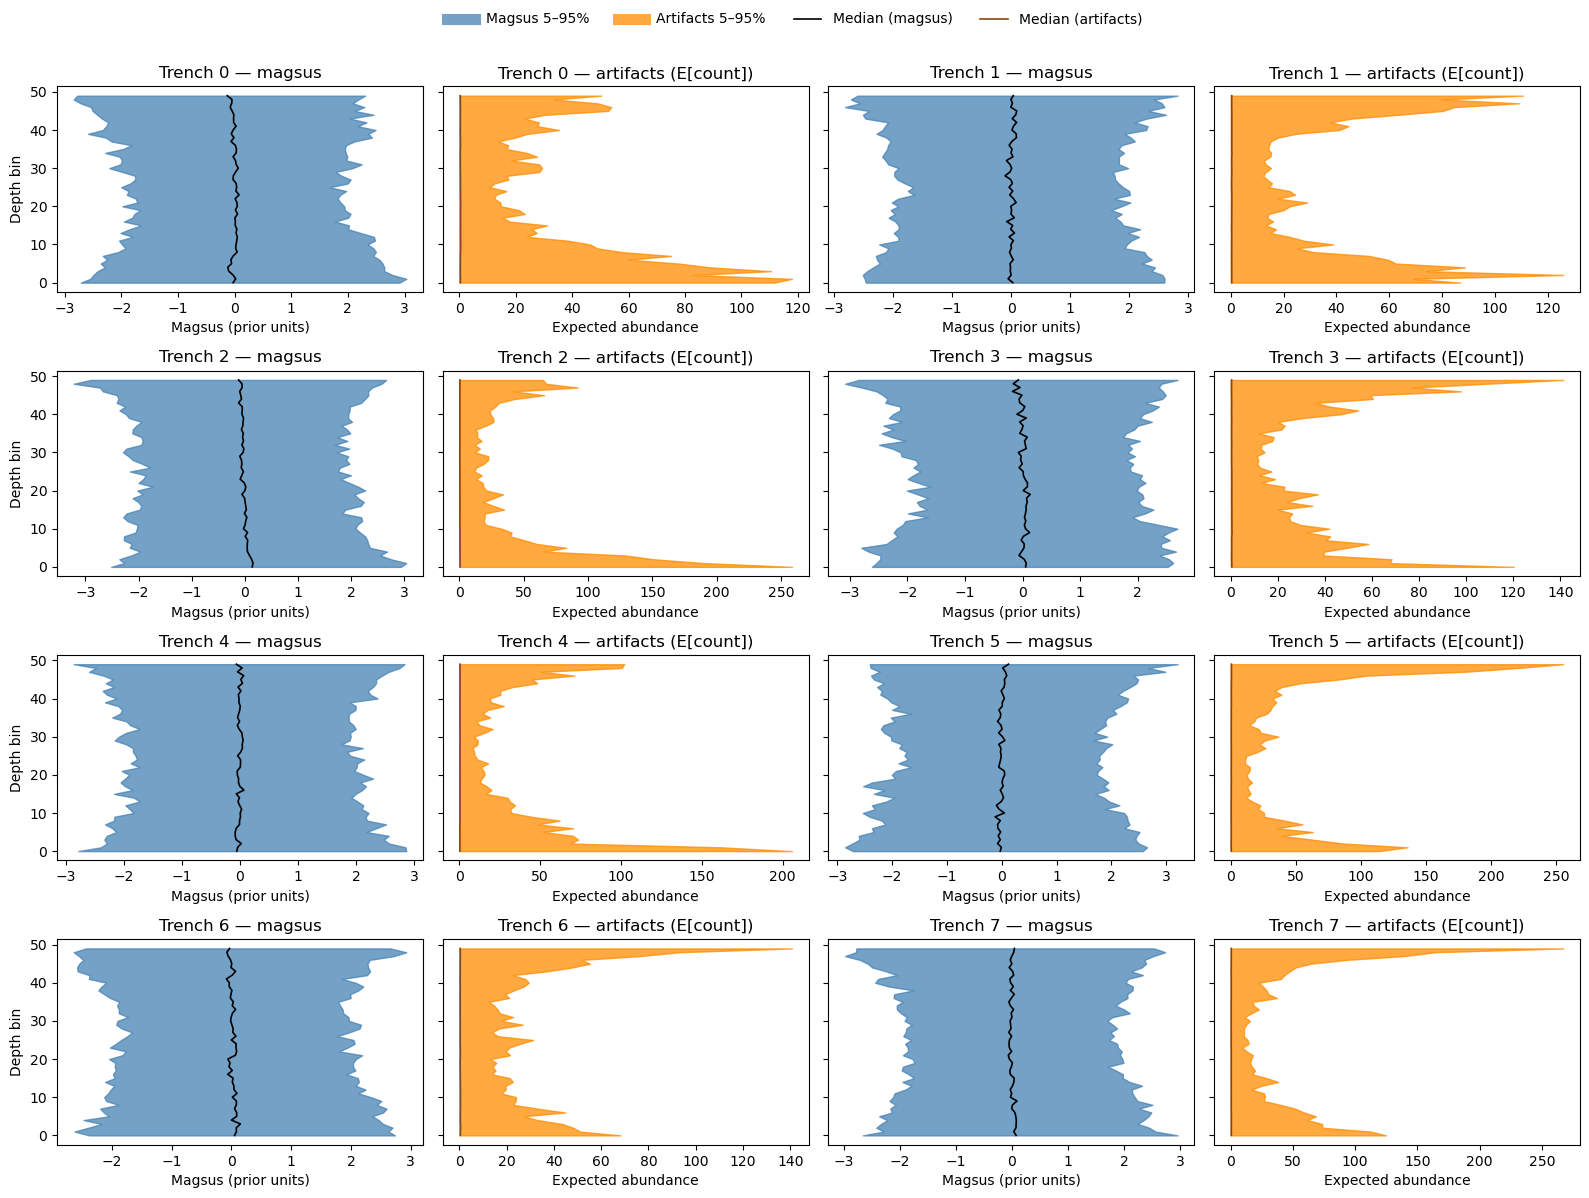

In [17]:
# Panel plot: per trench, side-by-side ribbons for magsus (left) and artifact abundance (right)
# Assumes you already have:
# - coords dict with "depth" and "trench"
# - `pri` InferenceData from prior predictive
# - helper `get_idata_var` defined earlier

import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# --- Grab draws
y_da  = get_idata_var(pri, "y")   # (chain, draw, depth, trench)
p_da  = get_idata_var(pri, "p")   # (chain, draw, depth, trench)
mu_da = get_idata_var(pri, "mu")  # (chain, draw, depth, trench)

# Stack chain/draw to one "s" axis for each var
y_vals  = y_da.stack(s=("chain","draw")).transpose("s","depth","trench").values
p_vals  = p_da.stack(s=("chain","draw")).transpose("s","depth","trench").values
mu_vals = mu_da.stack(s=("chain","draw")).transpose("s","depth","trench").values

# Unconditional expected abundance draws: E[x] = p * mu for each draw/depth/trench
ex_vals = p_vals * mu_vals  # shape (samples, depth, trench)

depth = coords["depth"]
T = len(coords["trench"])

# Layout: each trench gets two columns (left: magsus, right: artifacts)
trench_cols = 2
ncols_trenches = 2  # number of trenches per row; adjust if needed
ncols = ncols_trenches * trench_cols
nrows = ceil(T / ncols_trenches)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=True)
if nrows == 1:
    axes = np.atleast_2d(axes)  # ensure 2D for consistent indexing

def qbands(arr):
    # arr: (samples, depth) -> returns (q5, q50, q95) along samples
    return np.percentile(arr, [5, 50, 95], axis=0)

for t in range(T):
    row = t // ncols_trenches
    col_pair_start = (t % ncols_trenches) * trench_cols

    ax_y  = axes[row, col_pair_start]       # magsus
    ax_ex = axes[row, col_pair_start + 1]   # artifacts (expected abundance)

    # --- Magsus ribbon (steelblue) ---
    q5, q50, q95 = qbands(y_vals[:, :, t])
    ax_y.fill_betweenx(depth, q5, q95, color="steelblue", alpha=0.75, label="5–95% prior")
    ax_y.plot(q50, depth, color="black", lw=1.2, label="median")
    ax_y.set_title(f"Trench {t} — magsus")
    ax_y.set_xlabel("Magsus (prior units)")
    ax_y.set_ylabel("Depth bin" if col_pair_start == 0 else "")
    ax_y.invert_yaxis()

    # --- Artifact abundance ribbon (darkorange), using E[x] = p * μ ---
    aq5, aq50, aq95 = qbands(ex_vals[:, :, t])
    ax_ex.fill_betweenx(depth, aq5, aq95, color="darkorange", alpha=0.75, label="5–95% prior")
    ax_ex.plot(aq50, depth, color="saddlebrown", lw=1.2, label="median")
    ax_ex.set_title(f"Trench {t} — artifacts (E[count])")
    ax_ex.set_xlabel("Expected abundance")
    ax_ex.invert_yaxis()

# Clean up any extra empty axes if T doesn't fill the grid
total_panels = nrows * ncols_trenches
if T < total_panels:
    for t_pad in range(T, total_panels):
        row = t_pad // ncols_trenches
        col_pair_start = (t_pad % ncols_trenches) * trench_cols
        fig.delaxes(axes[row, col_pair_start])
        fig.delaxes(axes[row, col_pair_start + 1])

# One shared legend (optional): create dummy handles
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color="steelblue", lw=8, alpha=0.75, label="Magsus 5–95%"),
    Line2D([0], [0], color="darkorange", lw=8, alpha=0.75, label="Artifacts 5–95%"),
    Line2D([0], [0], color="black", lw=1.2, label="Median (magsus)"),
    Line2D([0], [0], color="saddlebrown", lw=1.2, label="Median (artifacts)"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


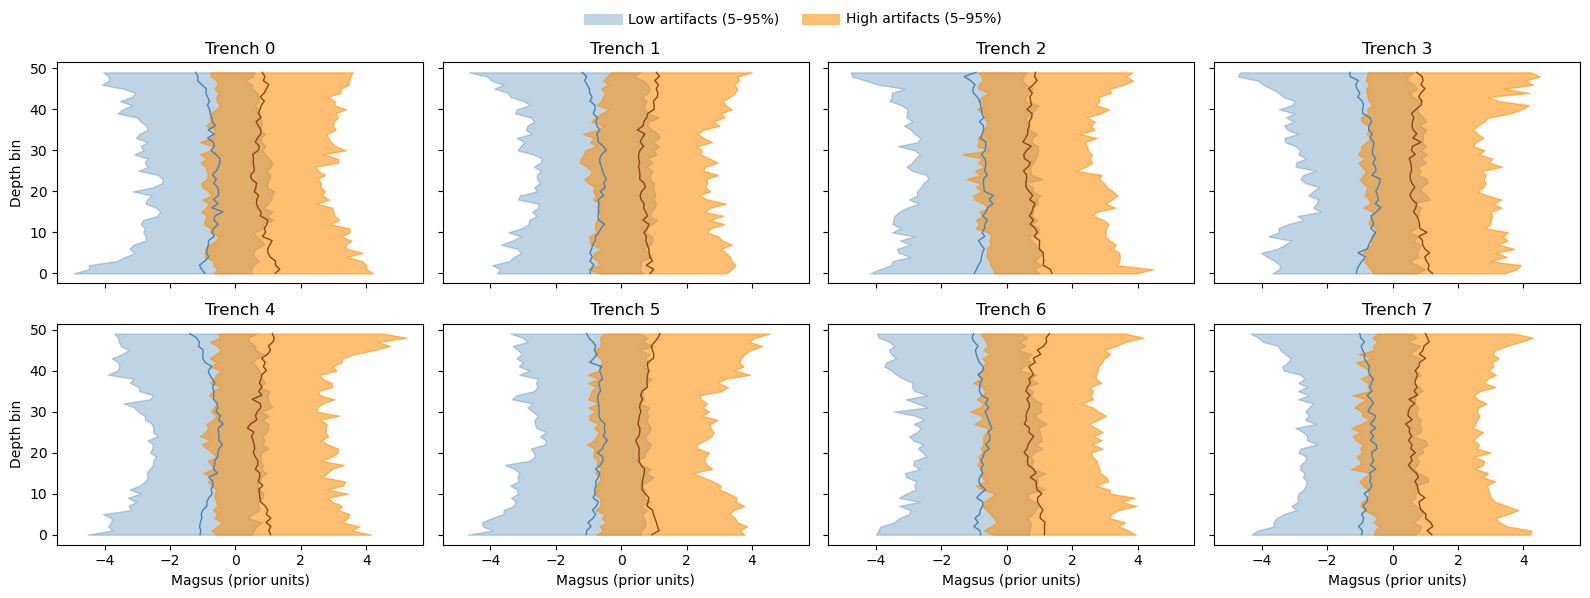

In [18]:
# Conditional ribbons: magsus given LOW vs HIGH artifact intensity
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

# pull draws
y_da  = get_idata_var(pri, "y")    # (chain, draw, depth, trench)
p_da  = get_idata_var(pri, "p")
mu_da = get_idata_var(pri, "mu")

y = y_da.stack(s=("chain","draw")).transpose("s","depth","trench").values
ex = (p_da * mu_da).stack(s=("chain","draw")).transpose("s","depth","trench").values  # E[count]

depth = coords["depth"]; T = len(coords["trench"])
ncols = 4; nrows = int(np.ceil(T/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharey=True, sharex=True)
axes = axes.flatten()

def qbands(arr):  # arr: (samples, depth)
    return np.percentile(arr, [5, 50, 95], axis=0)

for t in range(T):
    ax = axes[t]
    # per-depth thresholds on E[count]
    lo_thr = np.percentile(ex[:, :, t], 33, axis=0)
    hi_thr = np.percentile(ex[:, :, t], 67, axis=0)

    # boolean masks per sample-depth for low/high groups
    low_mask  = ex[:, :, t] <= lo_thr
    high_mask = ex[:, :, t] >= hi_thr

    # compress samples by masking
    y_low  = np.array([y[low_mask[:, d], d, t]  for d in range(len(depth))]).T
    y_high = np.array([y[high_mask[:, d], d, t] for d in range(len(depth))]).T

    q5L, q50L, q95L = qbands(y_low)
    q5H, q50H, q95H = qbands(y_high)

    # low artifacts ribbon (light)
    ax.fill_betweenx(depth, q5L, q95L, color="steelblue", alpha=0.35, label="magsus | low artifacts")
    ax.plot(q50L, depth, color="steelblue", lw=1)

    # high artifacts ribbon (shifted right)
    ax.fill_betweenx(depth, q5H, q95H, color="darkorange", alpha=0.55, label="magsus | high artifacts")
    ax.plot(q50H, depth, color="saddlebrown", lw=1)

    ax.set_title(f"Trench {t}")
    if t % ncols == 0: ax.set_ylabel("Depth bin")
    if t >= (nrows-1)*ncols: ax.set_xlabel("Magsus (prior units)")
    ax.invert_yaxis()

# legend
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color="steelblue", lw=8, alpha=0.35, label="Low artifacts (5–95%)"),
    Line2D([0],[0], color="darkorange", lw=8, alpha=0.55, label="High artifacts (5–95%)"),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0,0,1,0.96]); plt.show()


In [1]:
# Cell — Build model with RW1 + drift (no standardization), informative priors
import numpy as np
import pymc as pm
import pytensor.tensor as pt

# ---- Domain targets (edit to taste)
p0, p_hi  = 0.20, 0.70      # presence prob at I≈0 and I≈+2SD-ish
mu0, mu_hi = 2.0, 80.0      # mean counts | presence at I≈0 vs +2SD
phi_med   = 10.0            # NB dispersion

def logit(p): return np.log(p/(1-p))

alpha_z_mean = logit(p0)
beta_z_mean  = (logit(p_hi) - logit(p0)) / 2.0
alpha_x_mean = np.log(mu0)
beta_x_mean  = (np.log(mu_hi) - np.log(mu0)) / 2.0

# ---- Study design
T, D, R = 8, 50, 4  # trenches, depths, scans
coords = {"trench": np.arange(T), "depth": np.arange(D), "scan": np.arange(R), "depth_minus1": np.arange(D-1)}

with pm.Model(coords=coords) as model:
    # Latent I: RW1 with drift (per trench)
    sigma_I_t = pm.HalfNormal("sigma_I_t", 0.2, dims="trench")
    delta_t   = pm.Normal("delta_t", 0.02, 0.02, dims="trench")   # small positive drift per depth bin
    I0        = pm.Normal("I0", 0.0, 0.5, dims="trench")
    # increments with drift
    eps = pm.Normal("eps", delta_t, sigma_I_t, dims=("depth_minus1","trench"))
    I   = pm.Deterministic("I", pt.concatenate([I0[np.newaxis, :], I0[np.newaxis, :] + pt.cumsum(eps, axis=0)], axis=0),
                           dims=("depth","trench"))

    # Magsus channel (recommend standardized units in analysis; here prior units)
    alpha_y = pm.Normal("alpha_y", 0.0, 0.5)
    beta_y  = pm.Normal("beta_y",  1.0, 0.3)
    sigma_y = pm.HalfNormal("sigma_y", 0.4)
    sigma_scan = pm.HalfNormal("sigma_scan", 0.15)

    sigma_alpha_y = pm.HalfNormal("sigma_alpha_y", 0.3)
    sigma_beta_y  = pm.HalfNormal("sigma_beta_y",  0.3)
    alpha_y_t = pm.Normal("alpha_y_t", alpha_y, sigma_alpha_y, dims="trench")
    beta_y_t  = pm.Normal("beta_y_t",  beta_y,  sigma_beta_y,  dims="trench")

    y_mean = pm.Deterministic("y_mean", alpha_y_t + beta_y_t * I, dims=("depth","trench"))
    y      = pm.Normal("y", y_mean, sigma_y, dims=("depth","trench"))
    y_obs  = pm.Normal("y_obs", y[..., None], sigma_scan, observed=None, dims=("depth","trench","scan"))

    # Presence (inverse-link)
    alpha_z = pm.Normal("alpha_z", alpha_z_mean, 0.4)
    sigma_alpha_z = pm.HalfNormal("sigma_alpha_z", 0.4)
    alpha_z_t = pm.Normal("alpha_z_t", alpha_z, sigma_alpha_z, dims="trench")
    beta_z    = pm.Normal("beta_z",  beta_z_mean, 0.3)

    logit_p = alpha_z_t + beta_z * I
    p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims=("depth","trench"))
    z = pm.Bernoulli("z", p, observed=None, dims=("depth","trench"))

    # Abundance (hurdle-NB; mean on log-scale)
    alpha_x = pm.Normal("alpha_x", alpha_x_mean, 0.4)
    sigma_alpha_x = pm.HalfNormal("sigma_alpha_x", 0.4)
    alpha_x_t = pm.Normal("alpha_x_t", alpha_x, sigma_alpha_x, dims="trench")
    beta_x    = pm.Normal("beta_x",  beta_x_mean, 0.3)

    mu = pm.Deterministic("mu", pm.math.exp(alpha_x_t + beta_x * I), dims=("depth","trench"))
    phi = pm.HalfNormal("phi", sigma=phi_med)
    x = pm.NegativeBinomial("x", mu=mu, alpha=phi, observed=None, dims=("depth","trench"))


In [2]:
# Cell — Prior predictive and helper to fetch arrays robustly
import arviz as az
import numpy as np

def get_idata_var(idata, name, prefer=("prior_predictive","prior","posterior_predictive","posterior")):
    for grp in prefer:
        if hasattr(idata, grp) and getattr(idata, grp) is not None:
            ds = getattr(idata, grp)
            if name in ds.data_vars:
                return ds[name]
    raise KeyError(f"{name} not found")

with model:
    pri = pm.sample_prior_predictive(samples=500, random_seed=123)  # includes y, p, mu, x


Sampling: [I0, alpha_x, alpha_x_t, alpha_y, alpha_y_t, alpha_z, alpha_z_t, beta_x, beta_y, beta_y_t, beta_z, delta_t, eps, phi, sigma_I_t, sigma_alpha_x, sigma_alpha_y, sigma_alpha_z, sigma_beta_y, sigma_scan, sigma_y, x, y, y_obs, z]


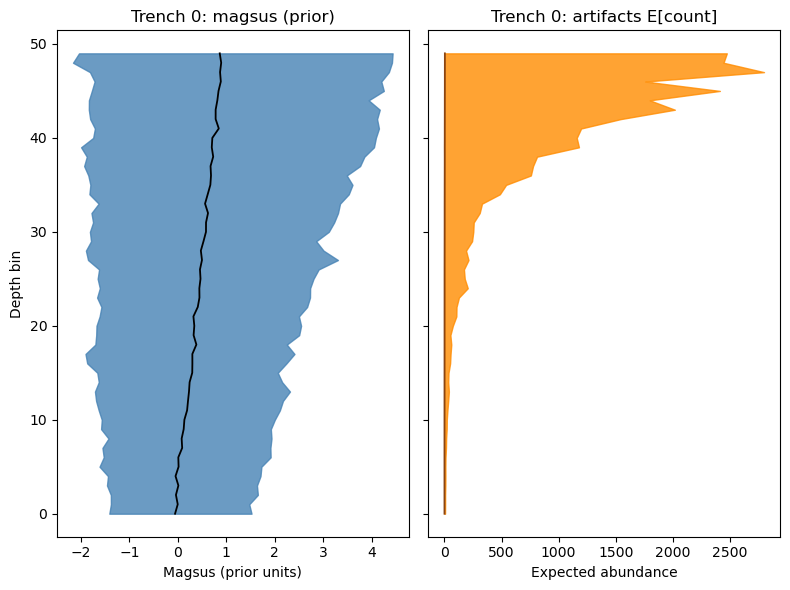

In [3]:
# Cell — Plot ONE trench (side-by-side) with depth vertical
import numpy as np
import matplotlib.pyplot as plt

t = 0  # choose trench index to show in SI

y_da  = get_idata_var(pri, "y").stack(s=("chain","draw")).transpose("s","depth","trench").values
p_da  = get_idata_var(pri, "p").stack(s=("chain","draw")).transpose("s","depth","trench").values
mu_da = get_idata_var(pri, "mu").stack(s=("chain","draw")).transpose("s","depth","trench").values
ex    = p_da * mu_da  # unconditional expected abundance

depth = np.arange(y_da.shape[1])

def qbands(arr):  # arr: (samples, depth)
    return np.percentile(arr, [5, 50, 95], axis=0)

y5,y50,y95   = qbands(y_da[:,:,t])
ex5,ex50,ex95 = qbands(ex[:,:,t])

fig, (ax_y, ax_x) = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# Magsus ribbon (blue)
ax_y.fill_betweenx(depth, y5, y95, alpha=0.8, color="steelblue", label="5–95% prior")
ax_y.plot(y50, depth, color="black", lw=1.3, label="median")
ax_y.set_title(f"Trench {t}: magsus (prior)")
ax_y.set_xlabel("Magsus (prior units)")
ax_y.set_ylabel("Depth bin")
ax_y.invert_yaxis()

# Artifacts expected abundance ribbon (orange)
ax_x.fill_betweenx(depth, ex5, ex95, alpha=0.8, color="darkorange", label="5–95% prior")
ax_x.plot(ex50, depth, color="saddlebrown", lw=1.3, label="median")
ax_x.set_title(f"Trench {t}: artifacts E[count]")
ax_x.set_xlabel("Expected abundance")
ax_x.invert_yaxis()

plt.tight_layout(); plt.show()


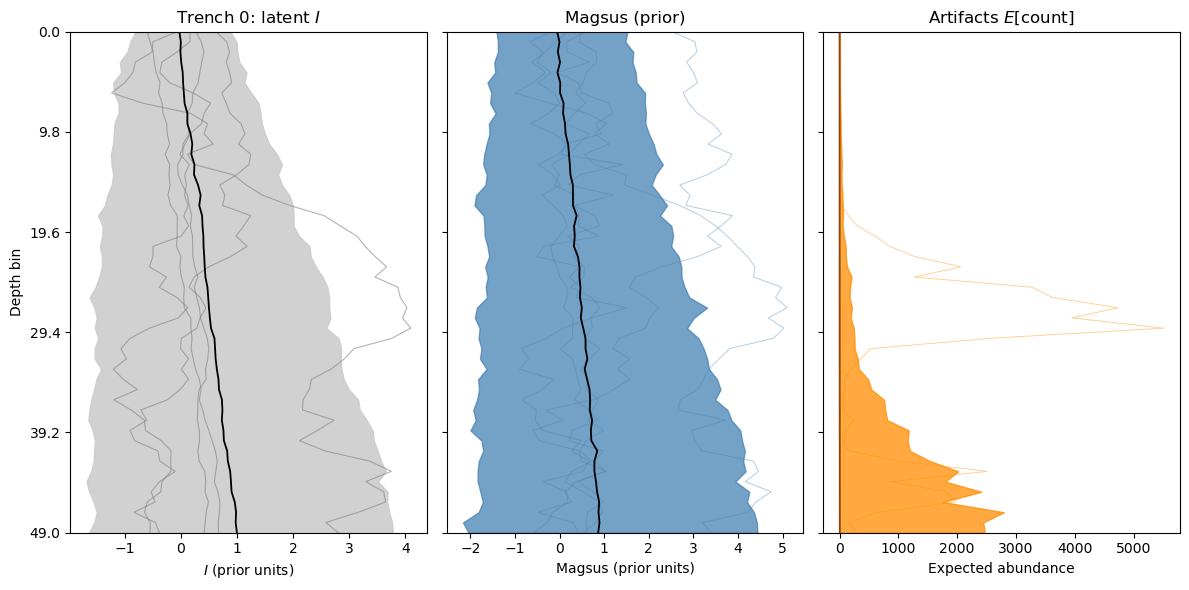

In [5]:
# Three-panel prior predictive plot: latent I, magsus, artifacts (E[count])
# Depth vertical (top=shallow, bottom=deep), robust axis flip via set_ylim.

import numpy as np
import matplotlib.pyplot as plt

t = 0  # trench index to show

# Pull arrays
I_da  = get_idata_var(pri, "I").stack(s=("chain","draw")).transpose("s","depth","trench").values
y_da  = get_idata_var(pri, "y").stack(s=("chain","draw")).transpose("s","depth","trench").values
p_da  = get_idata_var(pri, "p").stack(s=("chain","draw")).transpose("s","depth","trench").values
mu_da = get_idata_var(pri, "mu").stack(s=("chain","draw")).transpose("s","depth","trench").values
ex    = p_da * mu_da  # unconditional expected abundance

depth = np.arange(y_da.shape[1])

def qbands(arr):  # (samples, depth) -> q5,q50,q95 along samples
    return np.percentile(arr, [5, 50, 95], axis=0)

# Quantiles per panel
I5, I50, I95     = qbands(I_da[:, :, t])
y5, y50, y95     = qbands(y_da[:, :, t])
ex5, ex50, ex95  = qbands(ex[:, :, t])

# pick a few sample trajectories to overlay
rng = np.random.default_rng(123)
idx = rng.choice(I_da.shape[0], size=min(5, I_da.shape[0]), replace=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
ax_I, ax_y, ax_x = axes

# --- Latent I (gray/black)
for i in idx:
    ax_I.plot(I_da[i, :, t], depth, color="0.5", lw=0.8, alpha=0.6)
ax_I.fill_betweenx(depth, I5, I95, color="0.8", alpha=0.9, label="5–95% prior")
ax_I.plot(I50, depth, color="black", lw=1.3, label="median")
ax_I.set_title(f"Trench {t}: latent $I$")
ax_I.set_xlabel("$I$ (prior units)")
ax_I.set_ylabel("Depth bin")
ax_I.set_ylim(depth.max(), depth.min())  # <- robust flip (deep down)

# --- Magsus (steelblue)
for i in idx:
    ax_y.plot(y_da[i, :, t], depth, color="steelblue", lw=0.7, alpha=0.4)
ax_y.fill_betweenx(depth, y5, y95, color="steelblue", alpha=0.75, label="5–95% prior")
ax_y.plot(y50, depth, color="black", lw=1.3, label="median")
ax_y.set_title("Magsus (prior)")
ax_y.set_xlabel("Magsus (prior units)")
ax_y.set_ylim(depth.max(), depth.min())

# --- Artifacts expected abundance (darkorange)
for i in idx:
    ax_x.plot(ex[i, :, t], depth, color="darkorange", lw=0.7, alpha=0.4)
ax_x.fill_betweenx(depth, ex5, ex95, color="darkorange", alpha=0.75, label="5–95% prior")
ax_x.plot(ex50, depth, color="saddlebrown", lw=1.3, label="median")
ax_x.set_title("Artifacts $E[\\text{count}]$")
ax_x.set_xlabel("Expected abundance")
ax_x.set_ylim(depth.max(), depth.min())

# Optional: tidy y ticks to show shallow→deep clearly
ax_I.set_yticks(np.linspace(depth.min(), depth.max(), 6))

plt.tight_layout()
plt.show()
